In [1]:
# You work at a fictional company called Machine Learning Housing Corporation, and your job is to build a model 
# that can predict housing prices in California.

# Questions to ask or look at
# What data do you have?  population, median income, and median housing price for each block group in California etc.
# Frame the Problem: How does the company expect to use and benefit from this model?
# the model prediction will be fed to another ml system to predict investment. So accuracy matters, bad predictions mean bad investments.
# What is the current solution? manual estimation by experts using partial data and complex rules with 30% off estimates.
# meaning its slow and expensive ml can improve on this. Estimates is off by 30% ml have to beat that. Ml is used for investment decision.

# Answers
# Its a supervised problem because data are labelled, its a regression problem since price is to be predicted.
# its a multiple regression problem since we have many features to make a prediction. its a univariate since we are trying to predict 
# one value for a district and there is no continius flow of data so no need to change or adapt to new data and data is small enough.

In [2]:
# Firstly we need to understand the features provided to us 

# longitude measuring how far west or east a district is located in California. Lower values (around −124) are closer to the Pacific Ocean.
# latitude measuring how far north or south the district is. Higher values (around 38–40) are farther north.
# housing_median_age older houses have higher values. It gives an idea of neighborhood maturity.
# total_rooms The total number of rooms in all houses within the district
# total_bedrooms The total number of bedrooms in all houses within the district.
# population The total number of people living in the district.
# households The total number of groups of people sharing a home)
# median_income The median income of households in the district, measured in tens of thousands of dollars.
# median_house_value The median value of houses in the district, this is your target variable (what you’ll predict)
# ocean_proximity Describes how close the district is to the ocean.


# The steps to solve the problem include 

# Load data, → Inspect missing values, → Explore distributions, skewness, outliers, → Identify important features, → Create stratification category
# Stratify train/test, → Drop stratification column, → Making more useful categories, → Seperate Target from label,
# → Build pipeline (impute, scale, encode), → visualise to check difference, → Train models, → Evaluate, → Tune, → Final model.

In [1]:
# importing the basic libaries we need 

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# loading the data

from pathlib import Path

# a function for loading the data
def load_housing(local_path:None):
    url =  "https://raw.githubusercontent.com/ageron/data/main/housing/housing.csv"
    if local_path is not None and Path(local_path).is_file():
        return pd.read_csv(local_path)
    return pd.read_csv(url)

housing = load_housing(r"C:\Users\HP\Downloads\housing.csv") # path on my computer

In [3]:
print(housing.info())
print()
print(housing.isnull().sum()) # column total_bedrooms has 207 empty values
print()
print(housing.describe())

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  str    
dtypes: float64(9), str(1)
memory usage: 1.6 MB
None

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0


In [4]:
#  ocean_proximity is the only string so lets check the content out

print(housing['ocean_proximity'].value_counts())
print()
print(housing.dtypes.value_counts()) # to check different data types we have

ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64

float64    9
str        1
Name: count, dtype: int64


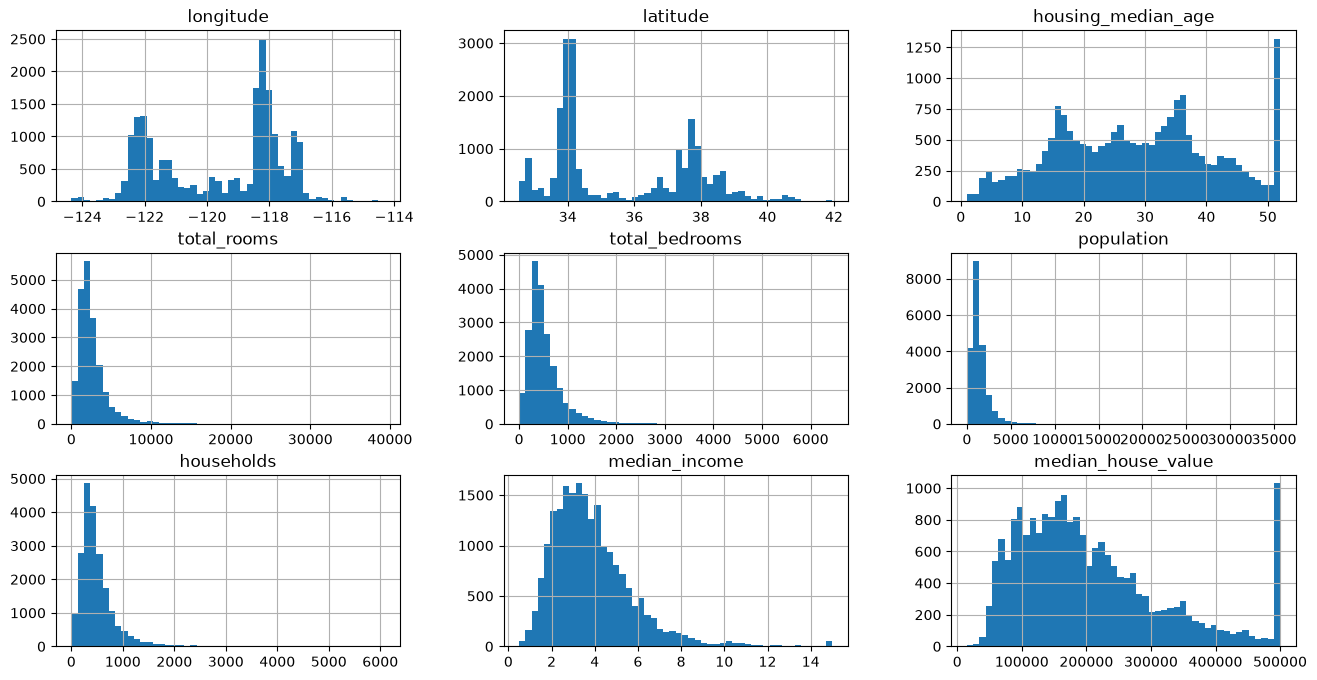

In [5]:
# lets explore with the use of histogram since we are dealing with numbers

housing.hist(bins=50, figsize=(16, 8))
plt.show()

# based on this diagam we can notice there is a right skewness as plot extend from left to right on total_rooms, total_bedrooms, 
# population, households. Which means we mostly have small values but we have few big values which can affect our model.

In [6]:
# lets check for skewness 

print(housing.skew(numeric_only=True))

# we can see the plot we have an extra moderate skewness on median income which we didn't pay attention on from histogram
# values > 0 are right skewed values < 0 are left skewed and value = 0 means normal distribution.

longitude            -0.297801
latitude              0.465953
housing_median_age    0.060331
total_rooms           4.147343
total_bedrooms        3.459546
population            4.935858
households            3.410438
median_income         1.646657
median_house_value    0.977763
dtype: float64


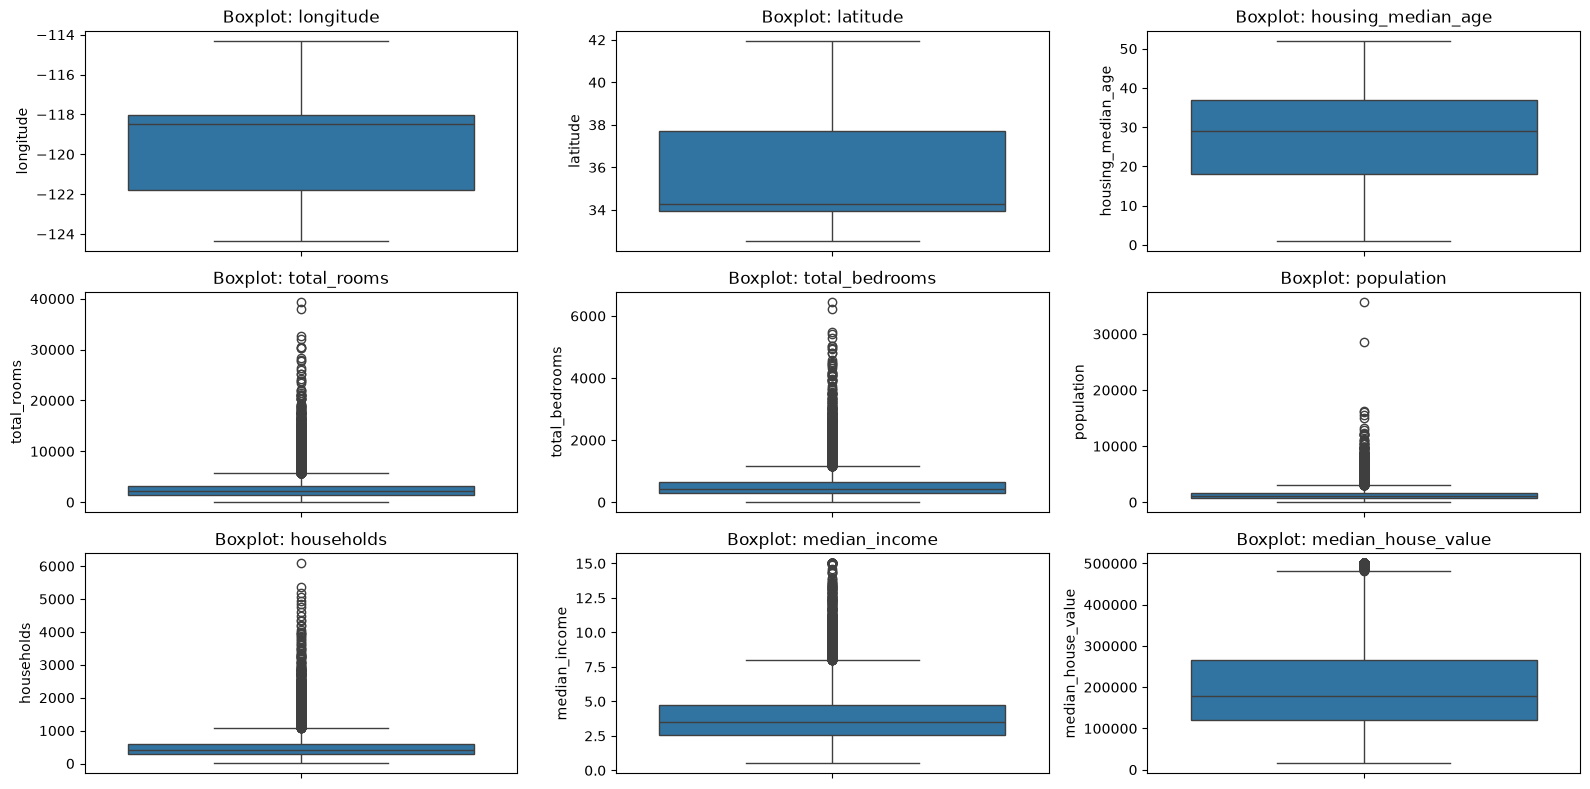

In [7]:
# lets check for outlier using boxplot because having a skewness doesn't necessary mean there is an outlier.

# Note: Each boxplot shows: Median → the middle line inside the box IQR (Interquartile Range) → the box (middle 50% of data)
# Whiskers → typical range of values. Dots outside whiskers → outliers

num_cols = housing.select_dtypes(include=['int64', 'float64']).columns # selecting all number columns


fig, axes = plt.subplots(3, 3, figsize=(16, 8))
axes = axes.flatten() # to make seperation of each plot easier

for col, ax in zip(num_cols, axes):
    sns.boxplot(housing[col], ax=ax)
    ax.set_title(f'Boxplot: {col}')

plt.tight_layout()
plt.show()

# there are outliers in the columns where we have skewness. Meaning some values are far apart from other values which can affect our model.

In [8]:
# lets check for correlation corresponding to our target value 

housing_corr = housing.corr(numeric_only=True)
print(housing_corr['median_house_value'].sort_values(ascending=False))

# the most correlated is median income meaning the target or prediction depends mostly on median income then total_rooms, housing_median_age
# minimally on households and total_bedrooms.

median_house_value    1.000000
median_income         0.688075
total_rooms           0.134153
housing_median_age    0.105623
households            0.065843
total_bedrooms        0.049686
population           -0.024650
longitude            -0.045967
latitude             -0.144160
Name: median_house_value, dtype: float64


In [9]:
# based on the fact that we have skewness and outliers in median income we need to ensure there is equal distribution of 
# it on train and test so we are stratifying based on median income.

# Making a new feature out of median income because we need labels or categories and it is in numbers
housing['income_cat']= pd.cut(housing['median_income'], bins=[0., 1.5, 3., 4.5, 6., np.inf], labels=[1, 2, 3, 4, 5])

# using a library to stratify shuffle and make a well balanced 80%, 10 different train set and 20% test set

from sklearn.model_selection import StratifiedShuffleSplit

splits=[]
splitter = StratifiedShuffleSplit(
    n_splits=10, test_size=0.2, random_state=42)

for train_ind, test_ind in splitter.split(housing, housing['income_cat']): # using split to add the data we are splitting and the labels need equally
    train = housing.iloc[train_ind].copy()
    test = housing.iloc[test_ind].copy()
    splits.append((train, test)) # one bracket is for append but two means its a tuple we are appending.

# selecting the first train data
strat_train, strat_test = splits[0]

# Print the percentage distribution of each income category in the stratified training and test sets. Using normalize=True shows proportions
# instead of raw counts, allowing us to verify that stratified sampling preserved the same category ratios in both splits.
print(strat_train['income_cat'].value_counts(normalize=True).sort_index())
print(strat_test['income_cat'].value_counts(normalize=True).sort_index())

income_cat
1    0.039789
2    0.318859
3    0.350594
4    0.176296
5    0.114462
Name: proportion, dtype: float64
income_cat
1    0.039971
2    0.318798
3    0.350533
4    0.176357
5    0.114341
Name: proportion, dtype: float64


In [10]:
# Removing the income_cat since we are done stratifying and its not needed

print('Keys before dropping', strat_train.keys())
print()

strat_train, strat_test = (
    strat_train.drop('income_cat', axis=1), 
    strat_test.drop('income_cat', axis=1))
print('Keys after dropping', strat_train.keys())

Keys before dropping Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'median_house_value', 'ocean_proximity', 'income_cat'],
      dtype='str')

Keys after dropping Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'median_house_value', 'ocean_proximity'],
      dtype='str')


In [11]:
# we can also make more correlated features

housing['bedroom_ratio'] = housing['total_rooms']/housing['total_rooms']
housing['people_per_house'] = housing['population']/housing['households']
housing['rooms_per_house'] = housing['total_rooms']/housing['households']

house_corr = housing.corr(numeric_only=True)
print(house_corr['median_house_value'].sort_values(ascending=False))

# we can see room_per_house is more correlated than total_rooms

median_house_value    1.000000
median_income         0.688075
rooms_per_house       0.151948
total_rooms           0.134153
housing_median_age    0.105623
households            0.065843
total_bedrooms        0.049686
people_per_house     -0.023737
population           -0.024650
longitude            -0.045967
latitude             -0.144160
bedroom_ratio              NaN
Name: median_house_value, dtype: float64


In [12]:
# Separate features and target from the stratified training set.
#We drop 'median_house_value' to create the feature matrix (housing), and store the target values separately in housing_labels.

housing = strat_train.copy()
housing = strat_train.drop('median_house_value', axis=1)
housing_labels = strat_train['median_house_value'].copy()

print(housing.keys())
print()
print(housing_labels.name)

Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'ocean_proximity'],
      dtype='str')

median_house_value


In [16]:
class ClusterSimilarity(BaseEstimator, TransformerMixin):
    def __init__(self, n_clusters=10, gamma=1.0):
        self.n_clusters = n_clusters
        self.gamma = gamma

    def fit(self, X, y=None):
        self.kmeans_ = KMeans(n_clusters=self.n_clusters, random_state=42)
        self.kmeans_.fit(X)
        return self

    def transform(self, X):
        return rbf_kernel(X, self.kmeans_.cluster_centers_, gamma=self.gamma)

    def get_feature_names_out(self, input_features=None):
        return np.array([f"geo_cluster_{i}_similarity" for i in range(self.n_clusters)])


In [17]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, FunctionTransformer
import numpy as np

# Identify numeric and categorical columns
num_cat = housing.select_dtypes(include=['int64', 'float64']).columns
str_cat = ['ocean_proximity']

# Skewed numeric columns
skew_cols = ['total_rooms', 'total_bedrooms', 'population', 'households', 'median_income']

# Split numeric columns
skewed_num = skew_cols
unskewed_num = [col for col in num_cat if col not in skew_cols]

# Pipeline for skewed numeric columns
skewed_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('log', FunctionTransformer(np.log1p, validate=True, feature_names_out='one-to-one')),
    ('scaler', StandardScaler())
])

# Pipeline for unskewed numeric columns
num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Pipeline for categorical columns
str_pipeline = Pipeline([
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

geo_pipeline = Pipeline([
    ("cluster", ClusterSimilarity(n_clusters=10, gamma=1.0))
])



# Full preprocessing pipeline
full_pipeline = ColumnTransformer([
    ('skewed', skewed_pipeline, skewed_num),
    ('num', num_pipeline, unskewed_num),
    ('str', str_pipeline, str_cat),
    ('geo', geo_pipeline, ['longitude', 'latitude'])   # ADDED HERE
])


housing_prepared = full_pipeline.fit_transform(housing)

In [18]:
# Convert the transformed NumPy array back into a DataFrame and attach the generated feature names from the pipeline. This allows us to inspect 
# exactly which features were created (including log‑transformed columns, scaled columns, and one‑hot encoded categorical features). 
# Printing each name helps verify that the ColumnTransformer applied all steps correctly and produced the expectedfeature set.

housing_prepared_df = pd.DataFrame(housing_prepared, columns=full_pipeline.get_feature_names_out())
for name in full_pipeline.get_feature_names_out():
    print(name)

skewed__total_rooms
skewed__total_bedrooms
skewed__population
skewed__households
skewed__median_income
num__longitude
num__latitude
num__housing_median_age
str__ocean_proximity_<1H OCEAN
str__ocean_proximity_INLAND
str__ocean_proximity_ISLAND
str__ocean_proximity_NEAR BAY
str__ocean_proximity_NEAR OCEAN
geo__geo_cluster_0_similarity
geo__geo_cluster_1_similarity
geo__geo_cluster_2_similarity
geo__geo_cluster_3_similarity
geo__geo_cluster_4_similarity
geo__geo_cluster_5_similarity
geo__geo_cluster_6_similarity
geo__geo_cluster_7_similarity
geo__geo_cluster_8_similarity
geo__geo_cluster_9_similarity


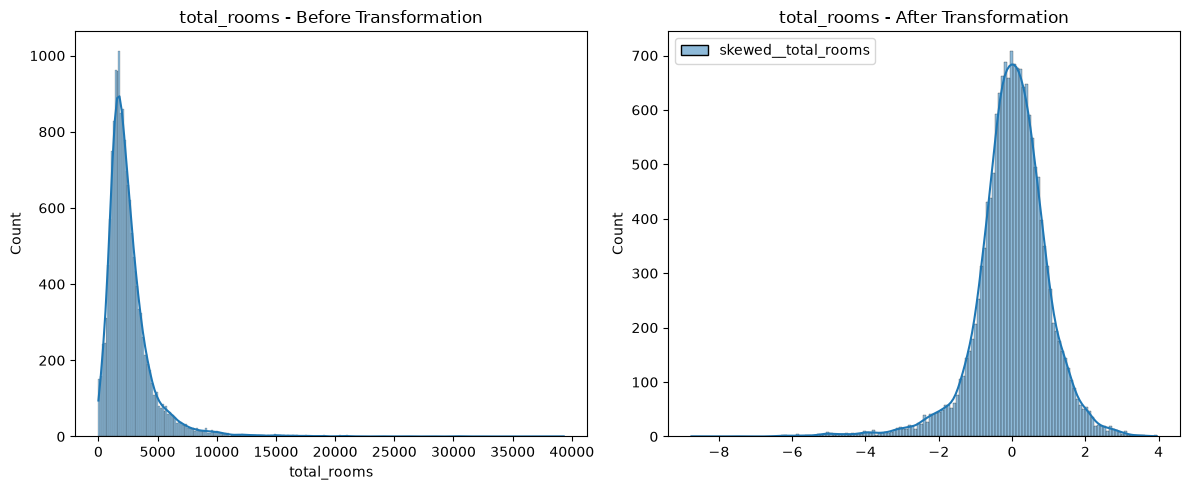

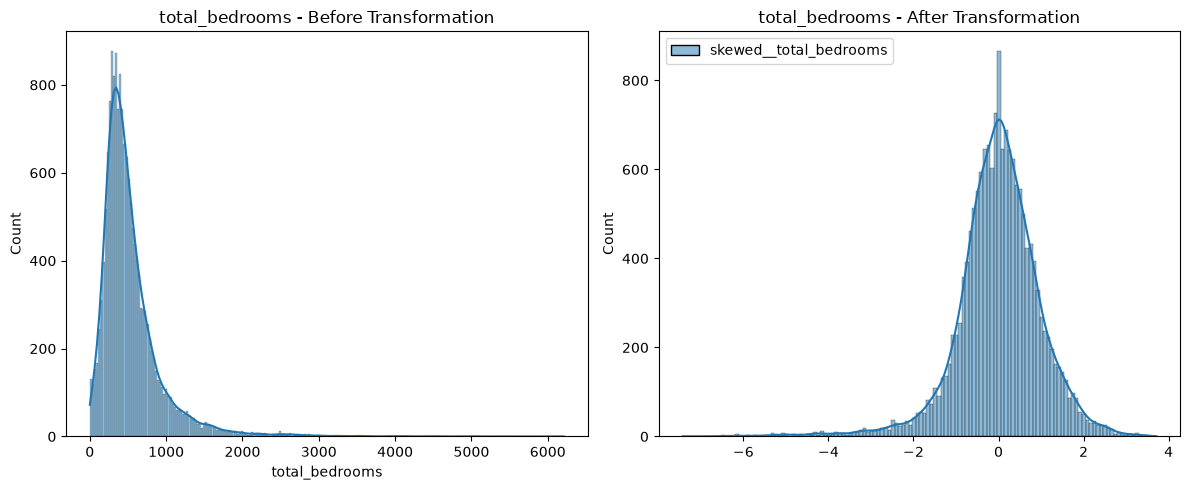

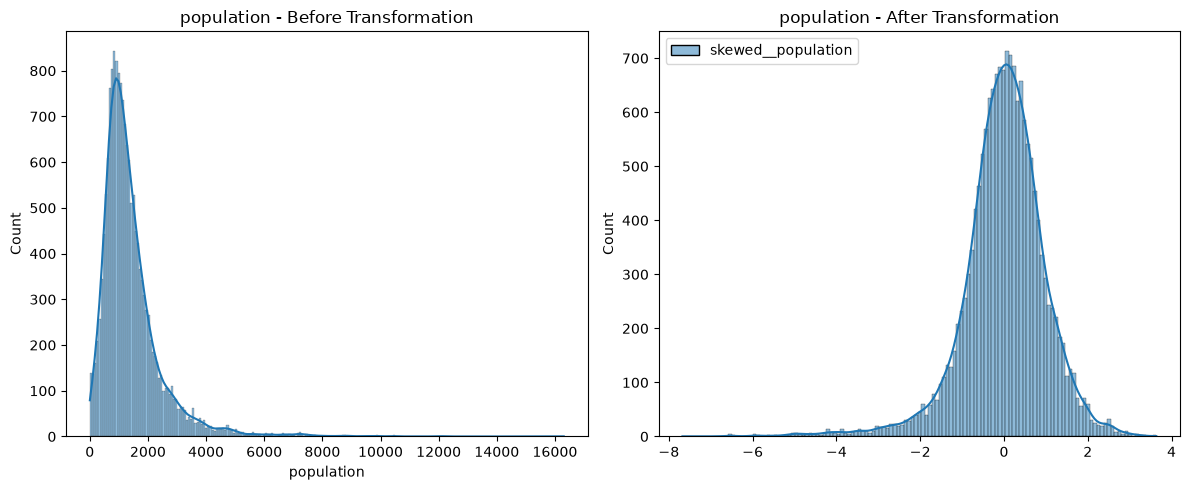

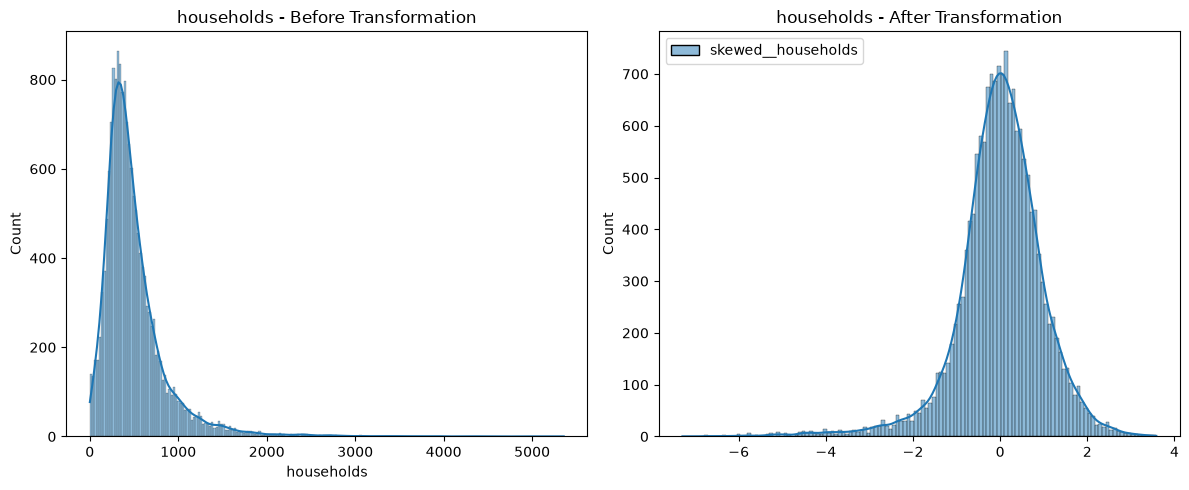

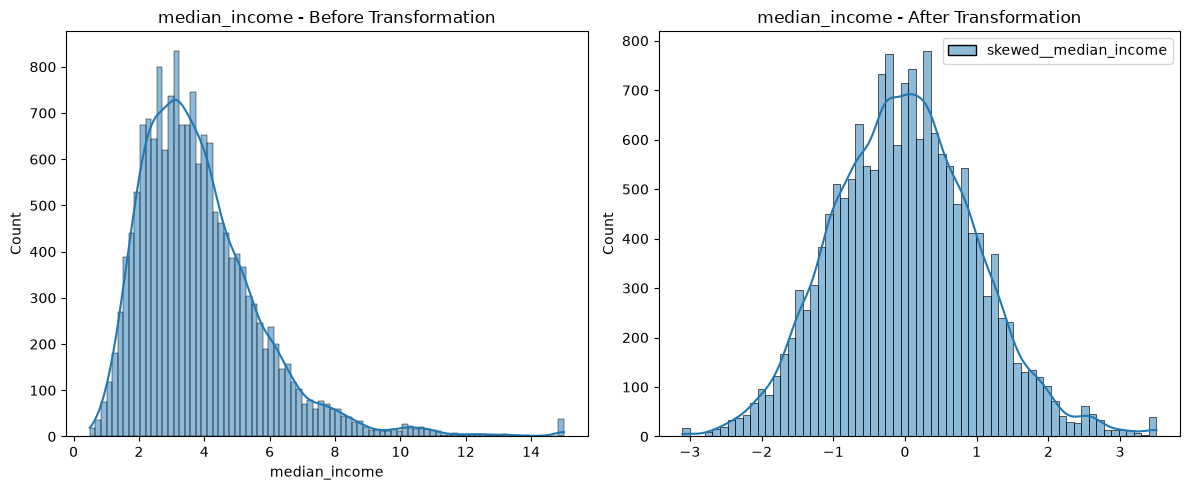

In [19]:
# visualise before and after cleaning transforming and scaling.

skewed_cols = ['total_rooms', 'total_bedrooms', 'population', 'households', 'median_income']
for col in skewed_cols:
    plt.figure(figsize=(12, 5))
    
    plt.subplot(1, 2, 1)
    sns.histplot(housing[col], kde=True)
    plt.title(f'{col} - Before Transformation')

    plt.subplot(1, 2, 2)
    transformed = housing_prepared_df.filter(like=col)
    sns.histplot(transformed, kde=True)
    plt.title(f'{col} - After Transformation')

    plt.tight_layout()
    plt.show()

In [20]:
# using linear regression
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LinearRegression

lr = make_pipeline(full_pipeline, LinearRegression())
lr.fit(housing, housing_labels)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('columntransformer', ...), ('linearregression', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](9,)","['longitude','latitude','housing_median_age',...,'households', 'median_income','ocean_proximity']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,9
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('skewed', ...), ('num', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be auto

In [21]:
housing_prediction = lr.predict(housing)
print(housing_prediction[:5].round(-2))
print(housing_labels[:5].values)

[245000. 373800. 133500.  88500. 324400.]
[458300. 483800. 101700.  96100. 361800.]


In [22]:
# make testing and labels

testing = strat_test.copy()
testing = strat_test.drop('median_house_value', axis=1)
testing_labels = strat_test['median_house_value'].copy()

In [23]:
testing_prediction = lr.predict(testing)
print(testing_prediction[:5].round(-2))
print(testing_labels[:5].values)

[356000. 263000. 364700. 294500. 279400.]
[397700. 202900. 310000. 314300. 187500.]


In [24]:
# getting the mean square error

from sklearn.metrics import mean_squared_error

mse = mean_squared_error(testing_labels, testing_prediction)
mse2 = mean_squared_error(housing_labels, housing_prediction)
print("MSE on test set:", mse)
print("MSE on train set:", mse2)

MSE on test set: 4806411959.449753
MSE on train set: 4542474473.774424


In [25]:
# printing the root mean square

rmse_test = np.sqrt(mse)
rmse_train = np.sqrt(mse2)

print("Actual RMSE on test set:", rmse_test)
print("Actual RMSE on train set:", rmse_train)

# MSE is the average squared prediction error; large values are expected because errors are squared.
# Train MSE < Test MSE indicates the model generalizes reasonably well.
# To interpret the error in real units (dollars), take the square root to obtain RMSE.

Actual RMSE on test set: 69328.2911908966
Actual RMSE on train set: 67397.88181964196


In [26]:
# making a Decision Tree Regressor

from sklearn.tree import DecisionTreeRegressor

tree = make_pipeline(full_pipeline, DecisionTreeRegressor(random_state=42))
tree.fit(housing, housing_labels)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('columntransformer', ...), ('decisiontreeregressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](9,)","['longitude','latitude','housing_median_age',...,'households', 'median_income','ocean_proximity']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,9
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('skewed', ...), ('num', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be

In [27]:
# Decision Trees can perfectly memorize the training data, so RMSE on the training set becomes 0.0. This indicates severe overfitting: the model fits
# every detail of the training set but will perform poorly on unseen data.


from sklearn.metrics import root_mean_squared_error


housing_prediction = tree.predict(housing)
tree_rmse= root_mean_squared_error(housing_labels, housing_prediction)
print(tree_rmse)

# A model with RMSE = 0.0 on training data is: too flexible, too deep, overfitted memorizing instead of learning
# therefore we have to use another model

0.0


In [28]:
# if data is plit once using train_test_split(), evaluation depends heavily on which samples happens to fall into the test set.
# which means:
# You might get lucky → test set is easy → model looks better than it really is
#You might get unlucky → test set is hard → model looks worse than it really is
# You get only one score, no idea how stable or reliable it is

# k‑Fold Cross‑Validation: it divides into equal fold number mentioned in cv run it the amount of fold nummber 
# it use 1 fold for test, 9 for training returns 10 scores one per fold
# giving us Mean performance → how good the model is. Standard deviation → how stable the model is.
# Why the Score Is Negative? Scikit‑Learn expects higher = better, but RMSE is a cost (lower = better).
# It flips the sign: It computes negative RMSE. You flip it back by adding a minus sign eg tree_rmses = -cross_val_score(...)

In [29]:
from sklearn.model_selection import cross_val_score

tree_rmses = -cross_val_score(
    tree,
    housing,
    housing_labels,
    scoring='neg_root_mean_squared_error',
    cv = 10
)

lr_rmses = -cross_val_score(
    lr,
    housing,
    housing_labels,
    scoring='neg_root_mean_squared_error',
    cv=10
)

print(pd.Series(tree_rmses).describe())
print()
print(pd.Series(lr_rmses).describe())

# Comparing both of them linear regression is slightly better it has lower error rate mean is more stab;e std and has more consistent min and max
# Linear Regression performs almost the same as the Decision Tree Decision Tree is slightly better, but not meaningfully
# Both models are underpowered for this dataset. Decision Tree is overfitting badly (training RMSE = 0)

count       10.000000
mean     64871.402611
std       1731.346589
min      62605.688282
25%      63665.131972
50%      64766.818946
75%      65633.217433
max      68069.531603
dtype: float64

count       10.000000
mean     67366.574547
std       1533.001489
min      64412.389519
25%      66590.910008
50%      67222.486854
75%      68430.678955
max      69680.744049
dtype: float64


In [30]:
# random forests work by training many decision trees on random subsets of the features, then averaging out their predictions

from sklearn.ensemble import RandomForestRegressor


forest = make_pipeline(full_pipeline, RandomForestRegressor(random_state=42))
forest.fit(housing, housing_labels)
forest_prediction = forest.predict(housing)

forest_rmses = -cross_val_score(
    forest,
    housing,
    housing_labels,
    scoring='neg_root_mean_squared_error',
    cv=10
)

forest_rmse = root_mean_squared_error(housing_labels, forest_prediction)
print(forest_rmse)
print(pd.Series(forest_rmses).describe())

17272.733370741516
count       10.000000
mean     46649.477031
std        690.046657
min      45217.319538
25%      46459.710606
50%      46720.909750
75%      46918.406239
max      47815.660994
dtype: float64


In [34]:
# Fine Tuning models is finding the best hyperparameters 
# hyperparameters are settings that control the model behaviour such as max_depth, n_estimators, max_features, n_clusters

# Grid search is used to fiddle with hyperparameters maually until the best combination of hyperparameter value is found 
# GridSearchCV Try all these settings and tell me which one gives the lowest RMSE
# Takes a model (or pipeline) Takes a dictionary of hyperparameters to try Trains the model on all combinations
# Uses cross‑validation to evaluate each combination Picks the best hyperparameters

forest_pipeline = Pipeline([
    ('ml_pipeline', full_pipeline),
    ('random_forest', RandomForestRegressor(random_state=42))
])

# defining the hyperparameter for the grid to find the best

param_grid = [
    {
        'ml_pipeline__geo__cluster__n_clusters': [5, 8, 10],
        'random_forest__max_features': [4, 6, 8]
    },
    {
        'ml_pipeline__geo__cluster__n_clusters': [10, 15],
        'random_forest__max_features': [6, 8, 10]
    }
]

forest_pipeline.get_params().keys()
# This grid means: Try 5, 8, 10 clusters with max_features 4, 6, 8 Try 10, 15 clusters with max_features 6, 8, 10

dict_keys(['memory', 'steps', 'transform_input', 'verbose', 'ml_pipeline', 'random_forest', 'ml_pipeline__n_jobs', 'ml_pipeline__remainder', 'ml_pipeline__sparse_threshold', 'ml_pipeline__transformer_weights', 'ml_pipeline__transformers', 'ml_pipeline__verbose', 'ml_pipeline__verbose_feature_names_out', 'ml_pipeline__skewed', 'ml_pipeline__num', 'ml_pipeline__str', 'ml_pipeline__geo', 'ml_pipeline__skewed__memory', 'ml_pipeline__skewed__steps', 'ml_pipeline__skewed__transform_input', 'ml_pipeline__skewed__verbose', 'ml_pipeline__skewed__imputer', 'ml_pipeline__skewed__log', 'ml_pipeline__skewed__scaler', 'ml_pipeline__skewed__imputer__add_indicator', 'ml_pipeline__skewed__imputer__copy', 'ml_pipeline__skewed__imputer__fill_value', 'ml_pipeline__skewed__imputer__keep_empty_features', 'ml_pipeline__skewed__imputer__missing_values', 'ml_pipeline__skewed__imputer__strategy', 'ml_pipeline__skewed__log__accept_sparse', 'ml_pipeline__skewed__log__check_inverse', 'ml_pipeline__skewed__log__fea

In [35]:
from sklearn.model_selection import GridSearchCV

grid_search = GridSearchCV(
    forest_pipeline,
    param_grid,
    cv=3,
    scoring='neg_root_mean_squared_error',
    n_jobs=1
)

grid_search.fit(housing, housing_labels)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","[{'ml_pipeline__geo__cluster__n_clusters': [5, 8, ...], 'random_forest__max_features': [4, 6, ...]}, {'ml_pipeline__geo__cluster__n_clusters': [10, 15], 'random_forest__max_features': [6, 8, ...]}]"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_root_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomple

In [40]:
print(-grid_search.best_score_)
print(grid_search.best_params_)

44385.37957779414
{'ml_pipeline__geo__cluster__n_clusters': 15, 'random_forest__max_features': 6}


In [38]:
cv_results = grid_search.cv_results_

pd.DataFrame(cv_results)[[
    'param_ml_pipeline__geo__cluster__n_clusters',
    'param_random_forest__max_features',
    'mean_test_score',
    'std_test_score'
]]

,param_ml_pipeline__geo__cluster__n_clusters,param_random_forest__max_features,mean_test_score,std_test_score
0,5,4,-45911.657657,409.162393
1,5,6,-46079.429396,161.909618
2,5,8,-46449.539099,168.782727
3,8,4,-45411.467325,396.199011
4,8,6,-45093.895199,226.942226
5,8,8,-45597.621008,147.514963
6,10,4,-44820.009130,469.463913
7,10,6,-44710.288950,363.309196
8,10,8,-45288.710057,276.362300
9,10,6,-44710.288950,363.309196


In [39]:
# Grid Search tries every combination of hyperparameters. This is fine when:
# You have few hyperparameters Each hyperparameter has few values But it becomes impossible when:
# You have many hyperparameters Each has many possible values Some hyperparameters are continuous

# Randomized Pick random hyperparameter value, Train model, Evaluate, Repeat n_iter times
# Randomized Search solves this by: Sampling random combinations Running for any number of iterations you choose
# Exploring continuous ranges efficiently Avoiding wasted time on hyperparameters that don’t matter

from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint

param_distribs = {
    'ml_pipeline__geo__cluster__n_clusters': randint(low=3, high=50),
    'random_forest__max_features': randint(low=2, high=20)
}

rnd_search = RandomizedSearchCV(
    forest_pipeline,                 # your pipeline with preprocessing + RF
    param_distributions=param_distribs,
    n_iter=10,
    cv=3,
    scoring='neg_root_mean_squared_error',
    random_state=42
)

rnd_search.fit(housing, housing_labels)

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'ml_pipeline__geo__cluster__n_clusters': <scipy.stats....00217876CA570>, 'random_forest__max_features': <scipy.stats....0021787637140>}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'neg_root_mean_squared_error'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",10
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``Randomized

In [41]:
print(-rnd_search.best_score_)
print()
print(rnd_search.best_params_)
print()
pd.DataFrame(rnd_search.cv_results_)[
    ['param_ml_pipeline__geo__cluster__n_clusters',
     'param_random_forest__max_features',
     'mean_test_score',
     'std_test_score']
]

43960.74226611547

{'ml_pipeline__geo__cluster__n_clusters': 45, 'random_forest__max_features': 9}



,param_ml_pipeline__geo__cluster__n_clusters,param_random_forest__max_features,mean_test_score,std_test_score
0,41,16,-44114.249520,302.521507
1,45,9,-43960.742266,635.064131
2,23,8,-44101.439097,638.608301
3,21,12,-44716.693600,346.205599
4,13,5,-44618.198064,587.776991
5,42,4,-45706.845694,776.637063
6,24,3,-45956.924373,750.800756
7,26,13,-44427.741212,259.031739
8,32,7,-44092.485333,819.216246
9,4,2,-48036.847605,603.499580


In [42]:
# EAnsemble methods are based on one core idea: A group of good but different models usually beats the best single model.
# This works because different models make different types of errors. When you combine them, the errors tend to cancel out.
# like asking multiple experts instead of relying on one person.

# Types of Ensemble Methods
#Averaging / Voting Ensembles: You train multiple models and combine their predictions: Regression: average the predictions
# Classification: majority vote e.g Train a RandomForestRegressor and a KNN model, then predict:
# Bagging (Bootstrap Aggregating) Train many models on different bootstrap samples.
# Random Forest = Bagging + Decision Trees.
# Boosting Models are trained sequentially, each correcting the previous one.
# Examples: AdaBoost, Gradient Boosting, XGBoost, LightGBM

In [44]:
from scipy import stats
import numpy as np
from sklearn.metrics import mean_squared_error

# 1. Prepare test data
X_test = strat_test.drop("median_house_value", axis=1)
y_test = strat_test["median_house_value"].copy()

# 2. Use best model from tuning
final_model = rnd_search.best_estimator_

# 3. Predictions
final_predictions = final_model.predict(X_test)

# 4. RMSE (manual because squared=False is not supported)
mse = mean_squared_error(y_test, final_predictions)
final_rmse = np.sqrt(mse)
print("Final RMSE:", final_rmse)

# 5. Confidence interval
squared_errors = (final_predictions - y_test) ** 2

interval = np.sqrt(
    stats.t.interval(
        0.95,
        len(squared_errors) - 1,
        loc=squared_errors.mean(),
        scale=stats.sem(squared_errors)
    )
)

print("95% confidence interval:", interval)

Final RMSE: 42970.63077531777
95% confidence interval: [40751.75262224 45080.42675789]


1.9.0
